# Practice Notebook: Gradient Descent in Multiple Variables

*A personal-practice notebook inspired by the gradient descent material in DeepLearning.AI's "Calculus for Machine Learning and Data Science" course.*

This notebook is **not** a copy of any graded assignment -- it's an original set of exercises that extends the single-variable gradient descent you've practiced before into **two variables**, using `numpy` arrays and the gradient $\nabla f$ instead of a single derivative.

You'll implement a generic multivariable gradient descent function once, then reuse it across several problems: a 2D "bowl" function, the 2D power line problem (revisited from your earlier analytical notebook -- now solved numerically), and a small linear regression fit -- a genuine machine learning application of exactly this technique.

**How to use this notebook:**
1. Work through each exercise, filling in the code where you see `### START CODE HERE ###`.
2. Run the test cell right after each exercise -- it will tell you if your implementation is correct.
3. If you get stuck, the **Solutions** section at the very end has full worked implementations. Try not to peek too early!


## Table of Contents
1. Imports
2. Exercise 1 -- Generic Multivariable Gradient Descent
3. Exercise 2 -- Minimizing a 2D Bowl Function
4. Exercise 3 -- Visualizing the Descent Path
5. Exercise 4 -- Learning Rate and Divergence
6. Exercise 5 -- The Power Line Problem, Revisited Numerically
7. Exercise 6 (Challenge) -- Linear Regression by Gradient Descent
8. Wrap-up
9. Solutions


## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)


## 2. Exercise 1 -- Generic Multivariable Gradient Descent

In one variable, the update rule was $x_{n+1} = x_n - \alpha f'(x_n)$. In multiple variables, the derivative is replaced by the **gradient vector** $\nabla f$, and the update becomes:

$$\mathbf{p}_{n+1} = \mathbf{p}_n - \alpha \, \nabla f(\mathbf{p}_n)$$

where $\mathbf{p}_n$ is now a point (a NumPy array), not just a number.

**Your task:** complete `gradient_descent_2d`, a generic function that takes *any* gradient function of two variables, a starting point, a learning rate, and a number of iterations, and returns the final point along with the full history of points visited (so you can plot the path later).


In [12]:
# GRADED FUNCTION: gradient_descent_2d
# Generic gradient descent for a function of two variables.
#
# Args:
#   grad_func (callable): takes (x, y) and returns a length-2 array/list [df/dx, df/dy]
#   p0 (array-like): starting point [x0, y0]
#   learning_rate (float): step size, alpha
#   num_iterations (int): number of update steps
#
# Returns:
#   p (np.ndarray): final point [x, y] after all iterations
#   history (list of np.ndarray): point visited at every iteration (including p0)

def gradient_descent_2d(grad_func, p0, learning_rate=0.1, num_iterations=200):
    ### START CODE HERE ###
    p = p0
    history = [p.copy()]
    # loop num_iterations times: compute the gradient at the current point,
    # take a step in the negative-gradient direction, and record the new point
    
    for _ in range(num_iterations):
        dp = grad_func(p[0], p[1])
        p[0] = p[0] - learning_rate * dp[0]
        p[1] = p[1] - learning_rate * dp[1]
        # The one liner in solution is quite neat - p = p - np.array(grad_func(*p)) -> *p is like unpacking
        history.append(p.copy())
    
    ### END CODE HERE ###
    return p, history


In [13]:
# Test cell -- a simple sanity check on f(x,y) = x^2 + y^2 (minimum at the origin)
def grad_simple(x, y):
    return np.array([2*x, 2*y])

p_final, hist = gradient_descent_2d(grad_simple, [3.0, -4.0], learning_rate=0.1, num_iterations=100)
print("Final point:", p_final)
print("Number of points in history:", len(hist))

assert np.allclose(p_final, [0, 0], atol=1e-2), f"Expected convergence near (0,0), got {p_final}"
assert len(hist) == 101, "History should include the starting point plus all 100 iterations"
assert np.allclose(hist[0], [3.0, -4.0]), "First entry in history should be the starting point"
print("Exercise 1 looks correct!")


Final point: [np.float64(6.111107929003464e-10), np.float64(-8.148143905337951e-10)]
Number of points in history: 101
Exercise 1 looks correct!


## 3. Exercise 2 -- Minimizing a 2D Bowl Function

Consider the function:

$$f(x,y) = 3(x-2)^2 + (y-4)^2$$

This is the same shape of function as the "sauna" temperature model from your gradient/partial-derivatives notebook -- a bowl with a single minimum.

**Your task:**
1. Implement `f(x, y)` and `grad_f(x, y)`.
2. Run your `gradient_descent_2d` from a starting point of $(0,0)$.
3. Confirm the result matches the minimum you'd find analytically by setting $\nabla f = 0$.


In [14]:
# GRADED FUNCTIONS: f, grad_f
def f(x, y):
    ### START CODE HERE ### (~ 1 line of code)
    result = 3 * (x - 2) ** 2 + (y - 4) ** 2
    ### END CODE HERE ###
    return result

def grad_f(x, y):
    ### START CODE HERE ### (~ 1-2 lines of code)
    result = np.array([6 * (x - 2), 2 * (y - 4)])
    ### END CODE HERE ###
    return result


In [15]:
# Test cell
p_final, hist = gradient_descent_2d(grad_f, [0.0, 0.0], learning_rate=0.1, num_iterations=200)
print("Gradient descent minimum:", p_final)
print("f at that point:", f(*p_final))

assert np.allclose(p_final, [2.0, 4.0], atol=1e-2), f"Expected convergence near (2, 4), got {p_final}"
assert np.isclose(f(*p_final), 0.0, atol=1e-2), "The minimum value of f should be (close to) 0"
print("Exercise 2 looks correct!")


Gradient descent minimum: [np.float64(2.0), np.float64(3.999999999999999)]
f at that point: 7.888609052210118e-31
Exercise 2 looks correct!


## 4. Exercise 3 -- Visualizing the Descent Path

Numbers are convincing, but a picture makes it click: gradient descent should trace a path that flows "downhill" toward the minimum, always moving in the direction of steepest decrease at each point.

**Your task:** using the `hist` list of points from Exercise 2 (or by re-running gradient descent), produce a contour plot of $f(x,y)$ and overlay the path gradient descent took to reach the minimum.


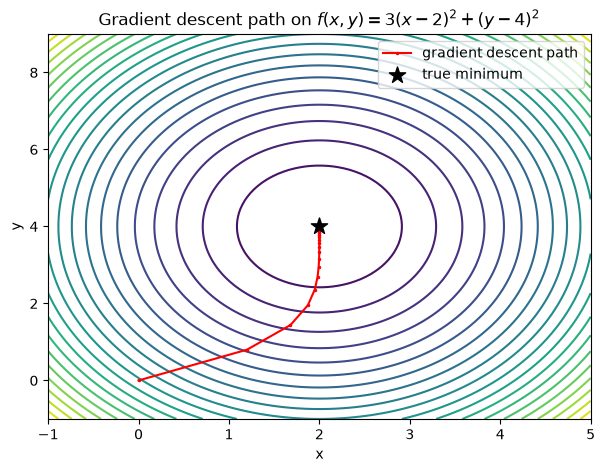

In [17]:
# GRADED CELL: visualize the descent path
p_final, hist = gradient_descent_2d(grad_f, [0.0, 0.0], learning_rate=0.1, num_iterations=200)
hist_array = np.array(hist)

### START CODE HERE ###
# 1. Create a grid of x, y values (e.g. with np.linspace and np.meshgrid) covering
#    roughly x in [-1, 5], y in [-1, 9]
# 2. Evaluate f on the grid to get Z
# 3. Use plt.contour(X, Y, Z, levels=20) to draw contour lines
# 4. Plot hist_array[:, 0] vs hist_array[:, 1] on top, as a line with markers,
#    to show the path gradient descent took
xg = np.linspace(-1, 5, 100)
yg = np.linspace(-1, 9, 100)
X, Y = np.meshgrid(xg, yg)
Z = f(X, Y)
### END CODE HERE ###

plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.plot(hist_array[:, 0], hist_array[:, 1], 'r.-', markersize=3, label="gradient descent path")
plt.scatter([2], [4], color='black', marker='*', s=150, zorder=5, label="true minimum")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Gradient descent path on $f(x,y) = 3(x-2)^2 + (y-4)^2$")
plt.legend()
plt.show()


## 5. Exercise 4 -- Learning Rate and Divergence

In the single-variable case, you saw that for $f(x) = ax^2$, gradient descent converges only when $0 < \alpha < \frac{1}{a}$. The same idea applies here, but now **each direction can have a different effective curvature**: for $f(x,y) = 3(x-2)^2 + (y-4)^2$, the $x$-direction behaves like $a=3$ and the $y$-direction behaves like $a=1$ -- so the $x$-direction has a *stricter* learning rate limit ($\alpha < \frac{1}{3}$) than the $y$-direction does ($\alpha < 1$).

**Your task:** run gradient descent with a learning rate that's safe for the $y$-direction but too large for the $x$-direction (e.g. $\alpha = 0.4$), for just 20 iterations, and observe what happens to each coordinate.


x-coordinate over the last 5 iterations: [ -433.59066756   611.82693459  -851.75770842  1197.26079179
 -1671.36510851]
y-coordinate over the last 5 iterations: [4. 4. 4. 4. 4.]


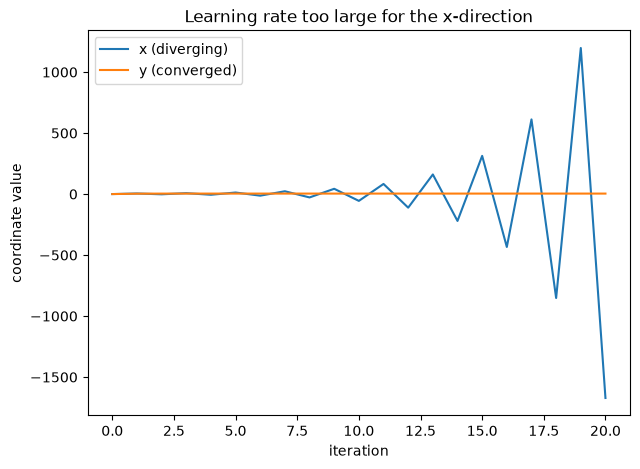

In [18]:
# GRADED CELL: explore an unstable learning rate
### START CODE HERE ###
p_final_unstable, hist_unstable = gradient_descent_2d(grad_f, [0.0, 0.0], learning_rate=0.4, num_iterations=20)   # call gradient_descent_2d with learning_rate=0.4, num_iterations=20
### END CODE HERE ###

hist_unstable_array = np.array(hist_unstable)
print("x-coordinate over the last 5 iterations:", hist_unstable_array[-5:, 0])
print("y-coordinate over the last 5 iterations:", hist_unstable_array[-5:, 1])

plt.plot(hist_unstable_array[:, 0], label="x (diverging)")
plt.plot(hist_unstable_array[:, 1], label="y (converged)")
plt.xlabel("iteration"); plt.ylabel("coordinate value")
plt.title("Learning rate too large for the x-direction")
plt.legend()
plt.show()


In [19]:
# Test cell
x_history = hist_unstable_array[:, 0]
y_history = hist_unstable_array[:, 1]

assert np.abs(x_history[-1]) > 100, "The x-coordinate should be diverging (growing large) with this learning rate"
assert np.isclose(y_history[-1], 4.0, atol=1e-2), "The y-coordinate should still have converged fine"
print("Exercise 4 looks correct -- same alpha, two very different outcomes per direction!")


Exercise 4 looks correct -- same alpha, two very different outcomes per direction!


## 6. Exercise 5 -- The Power Line Problem, Revisited Numerically

Recall the 2D power line problem: three cabins at $(1,2)$, $(4,6)$, and $(7,2)$ need to be connected to a single station, minimizing the total squared distance:

$$D(x,y) = \sum_{i=1}^{3} \left[(x - a_i)^2 + (y - b_i)^2\right]$$

You already solved this **analytically** in an earlier notebook (the answer was the centroid, $(4, \frac{10}{3})$). This time, solve it **numerically** with gradient descent, and confirm the two approaches agree.

**Your task:** implement `D(x, y)` and `grad_D(x, y)` for the three cabins below, then run gradient descent and compare to the known analytical answer.


In [22]:
# GRADED FUNCTIONS: D, grad_D
cabins = np.array([[1, 2], [4, 6], [7, 2]], dtype=float)

def D(x, y):
    ### START CODE HERE ### (~ 1-2 lines of code)
    result = np.sum((x - cabins[:, 0]) ** 2 + (y - cabins[:, 1]) ** 2)
    ### END CODE HERE ###
    return result

def grad_D(x, y):
    ### START CODE HERE ### (~ 1-3 lines of code)
    dx = np.sum(2 * (x - cabins[:, 0]))
    dy = np.sum(2 * (y - cabins[:, 1]))
    result = np.array([dx, dy])
    ### END CODE HERE ###
    return result


In [23]:
# Test cell
p_station, hist_station = gradient_descent_2d(grad_D, [0.0, 0.0], learning_rate=0.05, num_iterations=500)
print("Gradient descent station location:", p_station)

analytical_station = cabins.mean(axis=0)
print("Analytical station location (centroid):", analytical_station)

assert np.allclose(p_station, analytical_station, atol=1e-2), \
    f"Expected gradient descent to match the centroid {analytical_station}, got {p_station}"
print("Exercise 5 looks correct!")


Gradient descent station location: [np.float64(3.9999999999999996), np.float64(3.333333333333333)]
Analytical station location (centroid): [4.         3.33333333]
Exercise 5 looks correct!


## 7. Exercise 6 (Challenge) -- Linear Regression by Gradient Descent

This is the application that makes multivariable gradient descent so important in machine learning: fitting a model by minimizing a cost function over **multiple parameters at once**.

Given the small dataset below, fit a line $y = mx + b$ by minimizing the mean squared error:

$$C(m,b) = \frac{1}{n}\sum_{i=1}^{n} \left(y_i - (mx_i + b)\right)^2$$

**Your task:**
1. Implement `cost(m, b)`.
2. Implement `grad_cost(m, b)` -- this requires the partial derivatives $\frac{\partial C}{\partial m}$ and $\frac{\partial C}{\partial b}$ (use the chain rule on the squared term).
3. Run gradient descent to find the best-fit $m$ and $b$, and compare against NumPy's built-in least-squares solver as a sanity check.


In [28]:
# GRADED FUNCTIONS: cost, grad_cost
x_data = np.array([1, 2, 3, 4, 5], dtype=float)
y_data = np.array([2, 3, 5, 4, 6], dtype=float)

def cost(m, b):
    ### START CODE HERE ### (~ 1-2 lines of code)
    result = np.mean((y_data - (m * x_data + b) ** 2))
    ### END CODE HERE ###
    return result

def grad_cost(m, b):
    ### START CODE HERE ### (~ 1-4 lines of code)
    dcdm = np.mean(-2 * x_data * (y_data - (m * x_data + b)))
    dcdb = np.mean(-2 * (y_data - (m * x_data + b)))
    result = np.array([dcdm, dcdb])
    ### END CODE HERE ###
    return result


Gradient descent fit: m = 0.9000, b = 1.3000
NumPy least-squares fit: m = 0.9000, b = 1.3000


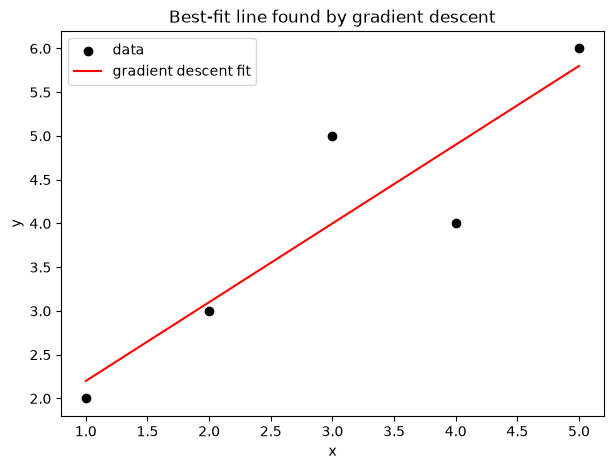

Exercise 6 looks correct!


In [29]:
# Test cell
mb_final, hist_mb = gradient_descent_2d(grad_cost, [0.0, 0.0], learning_rate=0.05, num_iterations=5000)
m_gd, b_gd = mb_final
print(f"Gradient descent fit: m = {m_gd:.4f}, b = {b_gd:.4f}")

A = np.vstack([x_data, np.ones_like(x_data)]).T
m_ls, b_ls = np.linalg.lstsq(A, y_data, rcond=None)[0]
print(f"NumPy least-squares fit: m = {m_ls:.4f}, b = {b_ls:.4f}")

plt.scatter(x_data, y_data, color='black', label="data", zorder=3)
plt.plot(x_data, m_gd*x_data + b_gd, color='red', label="gradient descent fit")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.title("Best-fit line found by gradient descent")
plt.show()

assert np.isclose(m_gd, m_ls, atol=1e-2), f"Expected slope close to {m_ls:.4f}, got {m_gd:.4f}"
assert np.isclose(b_gd, b_ls, atol=1e-2), f"Expected intercept close to {b_ls:.4f}, got {b_gd:.4f}"
print("Exercise 6 looks correct!")


## 8. Wrap-up

In this notebook you practiced:
- Generalizing the gradient descent update rule from a single derivative to a full **gradient vector**.
- Minimizing a 2D bowl function, and visualizing the descent path on a contour plot.
- Seeing how the **same learning rate** can be stable in one direction and unstable in another, depending on each direction's curvature.
- Re-solving the 2D power line problem **numerically**, and confirming it agrees with the analytical centroid answer.
- Using multivariable gradient descent for **linear regression** -- fitting both a slope and an intercept at once by minimizing a cost function, the same core idea behind training many machine learning models.

If everything above passed, nice work! If not, the **Solutions** section below has full reference implementations for every exercise.


## 9. Solutions

*Reference implementations -- try every exercise above on your own first!*


In [ ]:
# ----- Solution: Exercise 1 -----
def gradient_descent_2d(grad_func, p0, learning_rate=0.1, num_iterations=200):
    p = np.array(p0, dtype=float)
    history = [p.copy()]
    for _ in range(num_iterations):
        p = p - learning_rate * np.array(grad_func(*p))
        history.append(p.copy())
    return p, history


In [ ]:
# ----- Solution: Exercise 2 -----
def f(x, y):
    result = 3*(x - 2)**2 + (y - 4)**2
    return result

def grad_f(x, y):
    result = np.array([6*(x - 2), 2*(y - 4)])
    return result


In [ ]:
# ----- Solution: Exercise 3 -----
p_final, hist = gradient_descent_2d(grad_f, [0.0, 0.0], learning_rate=0.1, num_iterations=200)
hist_array = np.array(hist)

x_grid = np.linspace(-1, 5, 200)
y_grid = np.linspace(-1, 9, 200)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f(X, Y)

plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.plot(hist_array[:, 0], hist_array[:, 1], 'r.-', markersize=3, label="gradient descent path")
plt.scatter([2], [4], color='black', marker='*', s=150, zorder=5, label="true minimum")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Gradient descent path on $f(x,y) = 3(x-2)^2 + (y-4)^2$")
plt.legend()
plt.show()


In [ ]:
# ----- Solution: Exercise 4 -----
p_final_unstable, hist_unstable = gradient_descent_2d(grad_f, [0.0, 0.0], learning_rate=0.4, num_iterations=20)


In [ ]:
# ----- Solution: Exercise 5 -----
cabins = np.array([[1, 2], [4, 6], [7, 2]], dtype=float)

def D(x, y):
    result = np.sum((x - cabins[:, 0])**2 + (y - cabins[:, 1])**2)
    return result

def grad_D(x, y):
    dx = np.sum(2*(x - cabins[:, 0]))
    dy = np.sum(2*(y - cabins[:, 1]))
    result = np.array([dx, dy])
    return result


In [ ]:
# ----- Solution: Exercise 6 -----
x_data = np.array([1, 2, 3, 4, 5], dtype=float)
y_data = np.array([2, 3, 5, 4, 6], dtype=float)

def cost(m, b):
    pred = m*x_data + b
    result = np.mean((y_data - pred)**2)
    return result

def grad_cost(m, b):
    pred = m*x_data + b
    dm = np.mean(-2*x_data*(y_data - pred))
    db = np.mean(-2*(y_data - pred))
    result = np.array([dm, db])
    return result
